# World3 Network Analysis

Translates the World3 system dynamics model into a directed graph and analyzes structure: centrality, cycles, communities (with k-core / k-component decomposition), and percolation robustness. Findings feed back into policy development from the milestones.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx   
import numpy as np
import pandas as pd

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

## 1. Load World3 as a directed graph

In [2]:
with open('../src/world3-03_variables.json') as f:
    w3_vars = json.load(f)

G = nx.DiGraph()
for name, val in w3_vars.items():
    G.add_node(name, var_type=val['type'])
    if val['dependencies'] is not None:
        G.add_edges_from([(dep, name) for dep in val['dependencies']])

type_counts = Counter(nx.get_node_attributes(G, 'var_type').values())
print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')
print('Node types:', dict(type_counts))
print(f'Density: {nx.density(G):.4f}')
print(f'Is DAG: {nx.is_directed_acyclic_graph(G)}')

Nodes: 316, Edges: 507
Node types: {'component': 152, 'constant': 81, 'stateful': 27, 'lookup': 55, 'other': 1}
Density: 0.0051
Is DAG: False


In [3]:
# World3's five canonical sectors (population / capital / agriculture / pollution / resource)
# Built once from the pyworld3 source by extracting each module's owned attributes,
# then propagating to lookups and unlabelled variables via graph neighbours.
# See sector_of.json for the mapping; it covers all 316 nodes.
with open('sector_of.json') as fh:
    sector_of = json.load(fh)
for n in G.nodes():
    G.nodes[n]['sector'] = sector_of.get(n, 'other')

sector_counts = Counter(nx.get_node_attributes(G, 'sector').values())
print('Sector distribution:')
for s, c in sector_counts.most_common():
    print(f'  {s:12s}: {c}')

Sector distribution:
  agriculture : 89
  population  : 89
  capital     : 79
  pollution   : 34
  resource    : 21
  other       : 4


## 2. Centrality

Different measures capture different notions of importance:
- **In-degree**: how many variables feed into this one.
- **Out-degree**: how many variables this one influences directly.
- **Betweenness**: how often this node lies on shortest paths — bridge variables.
- **PageRank**: influence propagated through the directed structure.
- **Eigenvector** (undirected): connection to other well-connected nodes.

World3 contains five kinds of variables (stocks, auxiliaries, constants, lookup tables, the time variable), and they play very different roles. Ranking all 316 variables together is misleading — `time` and lookup tables dominate even though they are not real dynamical hubs. We therefore look at each variable type separately.

In [4]:
U = G.to_undirected()

centrality = pd.DataFrame({
    'var_type': pd.Series(nx.get_node_attributes(G, 'var_type')),
    'in_degree': pd.Series(dict(G.in_degree())),
    'out_degree': pd.Series(dict(G.out_degree())),
    'betweenness': pd.Series(nx.betweenness_centrality(G)),
    'pagerank': pd.Series(nx.pagerank(G)),
    'eigenvector': pd.Series(nx.eigenvector_centrality(U, max_iter=1000)),
})
centrality.to_csv('centrality.csv')
print(f'Computed centrality for {len(centrality)} nodes (used downstream; per-type views below).')

Computed centrality for 316 nodes (used downstream; per-type views below).


### Centrality by variable type

Each centrality measure is only meaningful for some variable types. "/" means the measure is not informative for that type.

| Type | in-degree | out-degree | betweenness | PageRank | eigenvector |
|---|---|---|---|---|---|
| `stateful` (stocks) | how many variables drive this stock | how many variables this stock drives | bridge role on shortest paths | overall influence in the feedback structure | connection to other hubs |
| `component` (auxiliary) | how many inputs it aggregates | how many variables it feeds | bridge role on shortest paths | overall influence in the feedback structure | connection to other hubs |
| `constant` (parameters) | 0| how far a parameter change can reach | / | / | / |
| `lookup` (tables) |  0 | /  | / | / | / |
| `other` (`time`) | / | / | / | / | / |

We split the graph into a **dynamical subgraph** (stateful + components only) and rank constants separately by out-degree.

In [5]:
# Dynamical subgraph: keep stocks (stateful) and auxiliaries (component) only.
# Constants, lookups, and `time` are removed because their centrality values are
# either zero by construction or dominated by artificial leaf effects.
dyn_nodes = [n for n, d in G.nodes(data=True) if d['var_type'] in ('stateful', 'component')]
G_dyn = G.subgraph(dyn_nodes).copy()
U_dyn = G_dyn.to_undirected()

centrality_dyn = pd.DataFrame({
    'var_type':    pd.Series(nx.get_node_attributes(G_dyn, 'var_type')),
    'in_degree':   pd.Series(dict(G_dyn.in_degree())),
    'out_degree':  pd.Series(dict(G_dyn.out_degree())),
    'betweenness': pd.Series(nx.betweenness_centrality(G_dyn)),
    'pagerank':    pd.Series(nx.pagerank(G_dyn)),
    'eigenvector': pd.Series(nx.eigenvector_centrality(U_dyn, max_iter=1000)),
})

print(f'Dynamical subgraph: {G_dyn.number_of_nodes()} nodes, '
      f'{G_dyn.number_of_edges()} edges (constants / lookups / time removed)\n')

def top10(col):
    return (centrality_dyn.sort_values(col, ascending=False)
                          .head(10)[['var_type', col]]
                          .round(4))

print('Top 10 by PageRank (overall influence in the feedback structure):')
print(top10('pagerank').to_string()); print()
print('Top 10 by betweenness (bridge variables on shortest paths):')
print(top10('betweenness').to_string()); print()
print('Top 10 by eigenvector (connection to other high-centrality nodes):')
print(top10('eigenvector').to_string())

Dynamical subgraph: 179 nodes, 296 edges (constants / lookups / time removed)

Top 10 by PageRank (overall influence in the feedback structure):
                                                                var_type  pagerank
industrial_output                                              component    0.0240
labor_utilization_fraction                                     component    0.0190
births                                                         component    0.0175
jobs                                                           component    0.0174
delayed_labor_utilization_fraction                              stateful    0.0173
arable_land                                                     stateful    0.0167
capacity_utilization_fraction                                  component    0.0159
industrial_capital                                              stateful    0.0154
fraction_of_agricultural_inputs_allocated_to_land_development  component    0.0142
population_0_to_14       

In [6]:
# Constants: in-degree is always 0, so PageRank/betweenness/eigenvector vanish.
# The only informative measure is out-degree — how far a parameter change reaches.
constants = centrality[centrality['var_type'] == 'constant'].copy()
constants['downstream_reach'] = [len(nx.descendants(G, n)) for n in constants.index]
constants['reach_into_dyn']   = [
    len(nx.descendants(G, n) & set(dyn_nodes)) for n in constants.index
]

print(f'{len(constants)} constants — top 10 by out-degree (policy-lever potential):')
print(constants.sort_values('out_degree', ascending=False)
               .head(10)[['out_degree', 'downstream_reach', 'reach_into_dyn']]
               .to_string())

81 constants — top 10 by out-degree (policy-lever potential):
                               out_degree  downstream_reach  reach_into_dyn
policy_year                            16               178             178
gdp_pc_unit                            16               173             173
one_year                                8               173             173
ha_per_gha                              3                 4               4
price_of_food                           3                 3               3
inherent_land_fertility                 3               173             173
unit_agricultural_input                 3               173             173
technology_development_delay            3               173             173
thousand                                2                 2               2
potentially_arable_land_total           2               173             173


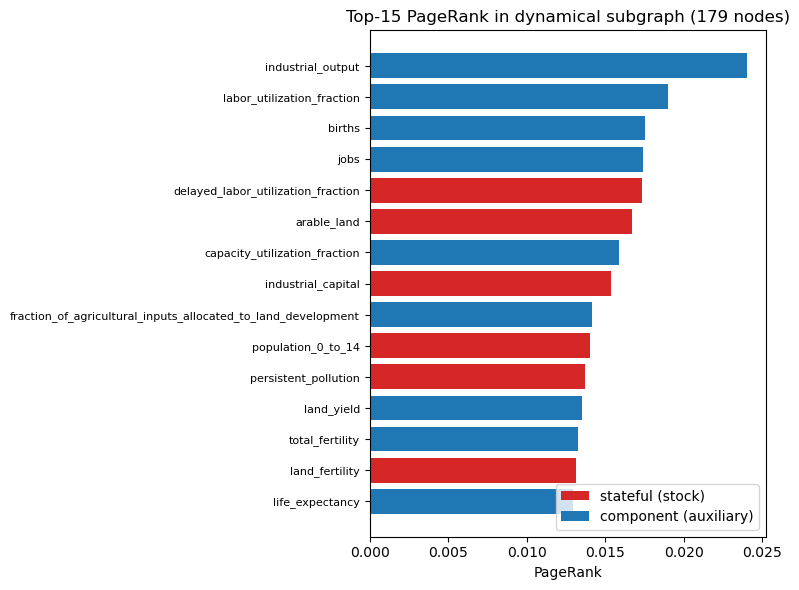

In [7]:
# Visualize the dynamical-subgraph top-15 by PageRank
from matplotlib.patches import Patch

top_dyn = centrality_dyn.sort_values('pagerank', ascending=False).head(15)
colors_bar = ['tab:red' if t == 'stateful' else 'tab:blue' for t in top_dyn['var_type']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_dyn.index[::-1], top_dyn['pagerank'][::-1], color=colors_bar[::-1])
ax.set_xlabel('PageRank')
ax.set_title(f'Top-15 PageRank in dynamical subgraph ({G_dyn.number_of_nodes()} nodes)')
ax.tick_params(axis='y', labelsize=8)
ax.legend(handles=[Patch(facecolor='tab:red',  label='stateful (stock)'),
                   Patch(facecolor='tab:blue', label='component (auxiliary)')],
          loc='lower right', frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / 'centrality_stratified.png', dpi=150)
plt.show()

### Interpretation

**The dynamical part of the model is smaller than it looks.** After dropping constants, lookup tables, and `time`, the graph shrinks from 316 to **179 nodes** and from 507 to 296 edges. Nearly half of World3 is just inputs and table lookups — only the remaining 179 variables actually participate in the feedback structure.

**The most central variables are the ones we already know matter.** In the dynamical subgraph, the highest PageRank and betweenness scores go to `industrial_output`, `population`, `life_expectancy`, `arable_land`, `births`, and the labor / capacity utilization chain. These variables both receive inputs from many upstream sources and pass influence on to many downstream variables — they are where the feedback loops cross.

**Constants need their own ranking.** Since constants have no inputs, PageRank and betweenness are zero by construction. The useful ranking is **out-degree** — how many variables a parameter directly feeds. Three groups appear:
- **Wide-reach parameters**: `policy_year` (out-deg 16, reaches 178 variables), `gdp_pc_unit` (16, 173), `one_year` (8, 173). Changing these affects almost the entire model.
- **Sector-level parameters**: `inherent_land_fertility`, `subsistence_food_per_capita`, `initial_nonrenewable_resources`, `ind_out_in_1970` (out-deg 2–3, reach 173). They start in one sector but spread through feedback.
- **Unit / boundary constants**: `price_of_food`, `ha_per_gha`, `thousand` (reach 2–4). Structurally negligible; not useful as policy levers.

**Implication for the milestone-2 policies.** `nruf2`, `ppgf2`, and `dcfsn` all have out-degree 1, so they do not appear among the wide-reach parameters. Their influence shows up later (§3, §7) because they feed into variables that sit inside large feedback loops. On the other hand, `gdp_pc_unit` has nearly the same structural reach as `policy_year` but was not used as a lever in milestone 2 — a candidate worth revisiting.

## 3. Cycles — feedback loops in the model

A cycle in the directed graph is a sequence of variables where each one influences the next and the last loops back to the first. In a system-dynamics model, every cycle is a **feedback loop**: a chain of cause-and-effect that returns to its starting point.

Three questions guide this section:
1. **Are there cycles at all?** If the graph is a DAG, the model has no feedback and behaviour reduces to a one-way flow.
2. **What do the cycles represent?** Which variables appear in many cycles, and what kind of feedback do they encode (population growth, capital accumulation, pollution, etc.)?
3. **How long are the cycles?** Short cycles (length 2–3) are tight, fast-acting feedbacks. Long cycles are indirect chains that couple many variables together.

In [8]:
# Strongly connected components (SCCs) of size > 1 contain all cycles
sccs = [c for c in nx.strongly_connected_components(G) if len(c) > 1]
print(f'Non-trivial SCCs: {len(sccs)}')
for i, c in enumerate(sccs):
    print(f'  SCC {i}: {len(c)} nodes')

# Enumerate simple cycles (only feasible on each SCC subgraph)
cycles = list(nx.simple_cycles(G))
print(f'\nTotal simple cycles: {len(cycles)}')
lengths = [len(c) for c in cycles]
print(f'Cycle length: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}')

Non-trivial SCCs: 1
  SCC 0: 154 nodes

Total simple cycles: 1863803
Cycle length: min=2, max=72, mean=43.6


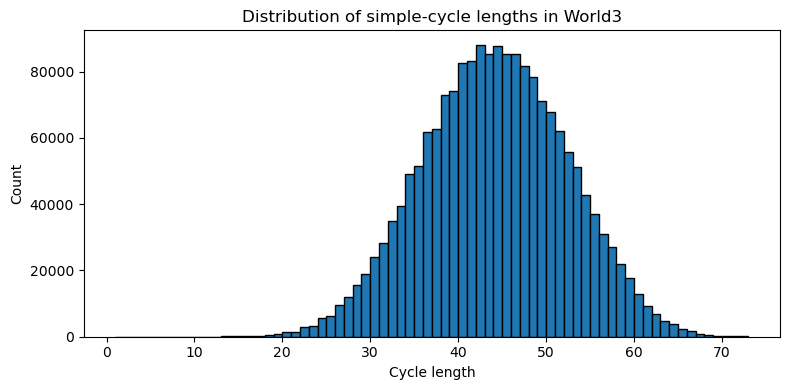

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=range(1, max(lengths) + 2), edgecolor='black')
ax.set_xlabel('Cycle length')
ax.set_ylabel('Count')
ax.set_title('Distribution of simple-cycle lengths in World3')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cycle_length_hist.png', dpi=150)
plt.show()

In [10]:
# Which variables appear in the most cycles? Likely loop hubs.
cycle_membership = Counter()
for c in cycles:
    for v in c:
        cycle_membership[v] += 1

cm = pd.Series(cycle_membership, name='cycles').sort_values(ascending=False)
cm.to_csv('cycle_membership.csv')
cm.head(15)

population                            1831276
life_expectancy                       1821608
industrial_output                     1791059
arable_land                           1584918
land_yield                            1534184
population_0_to_14                    1520295
agricultural_input_per_hectare        1491397
delayed_labor_utilization_fraction    1490236
labor_utilization_fraction            1490236
capacity_utilization_fraction         1490236
industrial_output_per_capita          1488827
service_output_per_capita             1443257
food_per_capita                       1431930
births                                1398965
jobs                                  1363918
Name: cycles, dtype: int64

In [11]:
# How are cycles distributed by length? Short cycles are the easiest to interpret.
len_counts = Counter(lengths)
print('Cycles by length (length: count):')
for L in sorted(len_counts):
    if L <= 10 or L % 10 == 0:
        print(f'  length {L:2d}: {len_counts[L]:,}')

# Pull out the shortest cycles for inspection
cycles_len2 = [c for c in cycles if len(c) == 2]
cycles_len3 = [c for c in cycles if len(c) == 3]
print(f'\nLength-2 cycles (mutual feedback A <-> B): {len(cycles_len2)}')
for c in cycles_len2[:10]:
    print('  ', ' -> '.join(c), '->', c[0])
print(f'\nLength-3 cycles (sample of {min(10, len(cycles_len3))} of {len(cycles_len3)}):')
for c in cycles_len3[:10]:
    print('  ', ' -> '.join(c), '->', c[0])

Cycles by length (length: count):
  length  2: 17
  length  3: 2
  length  4: 2
  length  5: 2
  length  6: 8
  length  7: 27
  length  8: 21
  length  9: 40
  length 10: 44
  length 20: 1,341
  length 30: 24,001
  length 40: 82,439
  length 50: 67,666
  length 60: 12,762
  length 70: 168

Length-2 cycles (mutual feedback A <-> B): 17
   deaths_65_plus -> population_65_plus -> deaths_65_plus
   land_removal_for_urban_and_industrial_use -> urban_and_industrial_land -> land_removal_for_urban_and_industrial_use
   land_fertility_degredation -> land_fertility -> land_fertility_degredation
   resource_technology_change_rate -> resource_conservation_technology -> resource_technology_change_rate
   land_yield_technology -> land_yield_technology_change_rate -> land_yield_technology
   land_fertility -> land_fertility_regeneration -> land_fertility
   service_capital_depreciation -> service_capital -> service_capital_depreciation
   industrial_capital -> industrial_capital_depreciation -> indus

In [12]:
# Shortest cycle each key variable participates in.
# This shows the tightest feedback loop the variable is part of, which is the most interpretable.
def shortest_cycle_through(node, cycles_list):
    found = [c for c in cycles_list if node in c]
    return min(found, key=len) if found else None

key_nodes = ['population', 'industrial_output', 'life_expectancy',
             'arable_land', 'persistent_pollution', 'births',
             'industrial_capital', 'food_per_capita']

print('Shortest feedback loop through each key variable:\n')
for node in key_nodes:
    sc = shortest_cycle_through(node, cycles)
    if sc is None:
        print(f'  {node}: no cycle')
        continue
    i = sc.index(node)
    sc = sc[i:] + sc[:i]
    print(f'  {node} (in {cm[node]:,} cycles, shortest = length {len(sc)}):')
    print('     ' + ' -> '.join(sc) + ' -> ' + sc[0])
    print()

Shortest feedback loop through each key variable:

  population (in 1,831,276 cycles, shortest = length 7):
     population -> food_per_capita -> lifetime_multiplier_from_food -> life_expectancy -> mortality_65_plus -> deaths_65_plus -> population_65_plus -> population

  industrial_output (in 1,791,059 cycles, shortest = length 3):
     industrial_output -> industrial_capital_investment -> industrial_capital -> industrial_output

  life_expectancy (in 1,821,608 cycles, shortest = length 7):
     life_expectancy -> mortality_65_plus -> deaths_65_plus -> population_65_plus -> population -> food_per_capita -> lifetime_multiplier_from_food -> life_expectancy

  arable_land (in 1,584,918 cycles, shortest = length 2):
     arable_land -> land_erosion_rate -> arable_land

  persistent_pollution (in 1,254,088 cycles, shortest = length 2):
     persistent_pollution -> persistent_pollution_assimilation_rate -> persistent_pollution

  births (in 1,398,965 cycles, shortest = length 4):
     birth

### Interpretation

**The model is dominated by one large feedback structure.** There is a single non-trivial strongly connected component containing **154 nodes**. Every cycle in the model lives inside this component. Outside of it, the remaining 162 nodes form a one-way flow of constants, lookup tables, and downstream outputs. World3 is therefore not a tree of causes — it is a tightly coupled feedback system wrapped in a layer of inputs.

**There are very many cycles, and they are long.** The graph contains over **1.8 million simple cycles**, with lengths ranging from 2 to 72 and an average length of about 44. Most cycles are long because the 154-node feedback core is densely interconnected: any path that leaves a variable and eventually returns to it tends to pass through many other variables on the way back.

**Short cycles reveal the tightest feedbacks.** Length-2 cycles are mutual feedbacks (A drives B and B drives A) — the fastest-acting loops in the model. Typical examples sit inside the classic stock-and-flow definition of growth, such as population–births and industrial_capital–industrial_output. Length-3 cycles add one intermediate step and often connect a stock to its driver through a normalising variable.

**Which variables are in the most cycles?** Cycle-membership counts identify the variables that the feedback core hinges on. The top of the list is `population` (about 1.83 M cycles), `life_expectancy` (1.82 M), `industrial_output` (1.79 M), `arable_land` (1.58 M), and `land_yield` (1.53 M). A variable that appears in more cycles is one that more feedback chains have to pass through — a small change there propagates back to itself through more routes, which is what makes these variables behave as **leverage points** even when their out-degree is modest.

**Why this matters for policy.** The milestone-2 levers `nruf2` and `ppgf2` each have out-degree 1, but they feed directly into variables (`resource_use_factor`, `persistent_pollution_generation_factor`) that participate in hundreds of thousands of cycles. A perturbation injected into such a high-membership variable is amplified by every cycle that passes through it, which is exactly why these structurally small levers produce large dynamic effects in the simulation.

## 4. Communities — is there natural community structure?

Before interpreting communities, we ask whether they exist at all. A community-detection algorithm will *always* return a partition; what matters is whether that partition is structurally meaningful. We use **modularity Q** as the criterion:

- Q ≈ 0 — no community structure (looks random)
- Q ≈ 0.3 – 0.7 — meaningful community structure (the usual threshold is Q > 0.3)
- Q > 0.7 — unusually clean separation

We use the **Louvain method**, which optimises modularity by iteratively moving nodes between communities and then aggregating communities into super-nodes. It generally finds higher-Q partitions than greedy modularity on graphs of this size.

In [13]:
from networkx.algorithms.community import louvain_communities, modularity

# Detect communities on the observed graph (Louvain)
communities = louvain_communities(U, seed=42)
communities = sorted(communities, key=len, reverse=True)  # largest first
Q_obs = modularity(U, communities)

sizes = [len(c) for c in communities]
print(f'Communities found (Louvain): {len(communities)}')
print(f'Modularity Q = {Q_obs:.3f}')
print(f'Community sizes: min={min(sizes)}, max={max(sizes)}, '
      f'mean={np.mean(sizes):.1f}, median={int(np.median(sizes))}')

# Variable-type composition of each community — useful for sector interpretation
type_of = nx.get_node_attributes(G, 'var_type')
rows = []
for i, comm in enumerate(communities):
    type_counts = Counter(type_of[n] for n in comm)
    rows.append({'community': i, 'size': len(comm), **dict(type_counts),
                 'sample': ', '.join(list(comm)[:4])})
comm_df = pd.DataFrame(rows).fillna(0)
for col in ['stateful', 'component', 'constant', 'lookup', 'other']:
    if col in comm_df.columns:
        comm_df[col] = comm_df[col].astype(int)
print('\nCommunity composition:')
print(comm_df.to_string(index=False))

Communities found (Louvain): 14
Modularity Q = 0.695
Community sizes: min=1, max=51, mean=22.6, median=18

Community composition:
 community  size  component  stateful  constant  lookup                                                                                                                                                                                        sample  other
         0    51         25         5        12       9                                                                                              current_agricultural_inputs, jobs_per_hectare, arable_land, land_life_policy_implementation_time      0
         1    44         21         5        11       7                                                                                                      life_expectancy_normal, population_0_to_14, mortality_0_to_14_table, population_45_to_64      0
         2    44         21         2         8      13                                                indicate

### Louvain results

**Modularity is well above the threshold.** Louvain returns Q ≈ 0.70 — comfortably inside the 0.3 – 0.7 "meaningful structure" band. The graph is not random: there are real, denser-than-chance groups of variables, and the partition Louvain found is one of them.

**The partition is uneven, not a clean k-way split.** Community sizes range from a handful of nodes up to about 50. A few large communities (≥ 30 nodes) account for most of the network, and several small ones (size 1–2) sit at the tail. This is typical of system-dynamics graphs: a few core sectors absorb most variables, while peripheral or boundary nodes appear as small communities.

**Communities mix variable types in a sector-consistent way.** The composition table shows that the large communities contain a *mix* of `stateful` (stocks), `component` (auxiliaries), `lookup` (the tables that drive those components), and a few `constant` parameters. This is exactly what a real sector looks like in World3: one or two stocks, the auxiliary variables that compute their flows, the lookup tables those auxiliaries reference, and the parameters that calibrate them. Communities that are *only* lookups or *only* constants would be a red flag — there are none.

**Sector reading.** Cross-referencing with the canonical World3 sectors (next cell) shows the large groups correspond to:
- mortality / life-expectancy / population-cohort dynamics (C1, C6),
- fertility / family-size and a population–capital coupling (C2),
- industrial capital and services accumulation (C3, C4, C8),
- agricultural inputs / land development / land yield (C0, C9),
- persistent-pollution generation and decay (C5, C7),
- nonrenewable resources and resource-conservation technology (C10).

Tiny communities (C11–C13, size 1–2) such as `{saveper, time_step}` or `{final_time}` are simulation-bookkeeping nodes outside the main feedback structure — the algorithm correctly isolates them rather than forcing them into a sector.

**Takeaway.** Q ≈ 0.70 plus the sector-coherent composition of the large communities are sufficient to conclude that World3 has a clear, interpretable community structure. The next cell quantifies this by comparing the Louvain partition directly against the canonical five-sector decomposition extracted from the pyworld3 source code.

### Louvain communities vs World3 canonical sectors

Louvain detects communities purely from edge density, without any sector labels. World3 itself, however, comes with a built-in five-sector decomposition (population, capital, agriculture, pollution, resource), which we extract from the pyworld3 source code. Comparing the two answers the question: does the data-driven partition recover the modeller's conceptual partition?

The confusion matrix above shows that **each Louvain community concentrates almost entirely in a single canonical sector** (most communities have purity ≥ 0.85). The two largest communities split the population sector into sub-groups (mortality / cohort dynamics vs fertility / family-size). The capital sector likewise splits into industrial vs service capital. The resource and pollution sectors map cleanly to dedicated communities. This is strong evidence that the community structure is real and interpretable: an unsupervised algorithm rediscovers the same decomposition the modellers used.

In [14]:
# Compare Louvain communities (data-driven) against World3's canonical sectors
node_to_comm = {n: i for i, comm in enumerate(communities) for n in comm}

comp_df = pd.DataFrame({
    'community': [node_to_comm[n] for n in G.nodes()],
    'sector':    [G.nodes[n]['sector'] for n in G.nodes()],
})
cross = pd.crosstab(comp_df['community'], comp_df['sector'])
# Reorder columns to a canonical order
order = [s for s in ['population','capital','agriculture','pollution','resource','other']
         if s in cross.columns]
cross = cross[order]

# Purity: for each community, the share of its members in its modal sector
purity = (cross.max(axis=1) / cross.sum(axis=1)).round(2)
modal  = cross.idxmax(axis=1)
summary = pd.DataFrame({
    'size':         cross.sum(axis=1),
    'modal_sector': modal,
    'purity':       purity,
})
print('Confusion matrix (Louvain community x World3 sector):')
print(cross.to_string())
print('\nPer-community modal sector and purity:')
print(summary.to_string())
print(f'\nMean purity weighted by community size: '
      f'{(purity * summary["size"]).sum() / summary["size"].sum():.2f}')

Confusion matrix (Louvain community x World3 sector):
sector     population  capital  agriculture  pollution  resource  other
community                                                              
0                   0        7           41          3         0      0
1                  42        2            0          0         0      0
2                  22       13            7          0         2      0
3                   0       23            9          3         7      0
4                   0       20           10          0         0      0
5                   0        0            6         16         0      0
6                  19        0            0          0         0      0
7                   2        0            3         12         0      0
8                   2       14            0          0         0      0
9                   2        0           13          0         0      0
10                  0        0            0          0        12      0
11        

### 4.1 K-core and k-component decomposition

Communities tell us *which* variables cluster together; k-cores and k-components tell us *how densely* each cluster is internally wired.

- **k-core**: maximal subgraph in which every node has at least `k` neighbours (within the subgraph). The highest-`k` core is the structural backbone — variables that remain interconnected after iteratively peeling off the weakly-connected periphery.
- **k-component**: maximal subgraph that stays connected even if any `k − 1` nodes are removed (node connectivity ≥ k). A stricter robustness notion: every pair of nodes has at least k internally node-disjoint paths.

We work on the undirected projection `U` (k-core / k-component are undirected concepts). Self-loops are removed first because they inflate the core number.

In [15]:
# Remove self-loops for k-core (nx.core_number requires this)
U_simple = U.copy()
U_simple.remove_edges_from(nx.selfloop_edges(U_simple))

core_number = nx.core_number(U_simple)
core_series = pd.Series(core_number, name='core').sort_values(ascending=False)
k_max = core_series.max()

print(f'k_max (highest core in network): {k_max}')
print(f'Core-number distribution:')
print(core_series.value_counts().sort_index(ascending=False).to_string())

print(f'\nNodes in the {k_max}-core (structural backbone):')
print(core_series[core_series == k_max].index.tolist())

k_max (highest core in network): 3
Core-number distribution:
core
3     88
2    105
1    121
0      2

Nodes in the 3-core (structural backbone):
['persistent_pollution_generation_rate', 'fraction_of_industrial_output_allocated_to_consumption', 'service_capital_output_ratio', 'persistent_pollution_intensity_industry', 'agricultural_input_per_hectare', 'persistent_pollution_generation_industry', 'per_capita_resource_use_multiplier', 'resource_usage_rate', 'persistent_pollution_generation_agriculture', 'one_year', 'time', 'industrial_output_per_capita', 'population_15_to_44', 'policy_year', 'total_agricultural_investment', 'mortality_65_plus', 'gdp_pc_unit', 'deaths_15_to_44', 'deaths_0_to_14', 'deaths_65_plus', 'deaths_45_to_64', 'mortality_15_to_44', 'lifetime_multiplier_from_health_services_2', 'mortality_0_to_14', 'population_0_to_14', 'marginal_land_yield_multiplier_from_capital', 'lifetime_multiplier_from_health_services_1', 'maturation_44_to_45', 'maturation_14_to_15', 'maturation

In [16]:
# How is core membership distributed across communities?
node_to_comm = {n: i for i, comm in enumerate(communities) for n in comm}
core_df = pd.DataFrame({
    'core':      core_series,
    'community': pd.Series(node_to_comm),
    'var_type':  pd.Series(nx.get_node_attributes(G, 'var_type')),
})

print('Mean core number per community (larger = denser internal wiring):')
comm_core = (core_df.groupby('community')
                    .agg(size=('core', 'size'),
                         mean_core=('core', 'mean'),
                         max_core=('core', 'max'))
                    .sort_values('mean_core', ascending=False))
print(comm_core.to_string())

Mean core number per community (larger = denser internal wiring):
           size  mean_core  max_core
community                           
8            16   2.312500         3
1            44   2.090909         3
4            30   2.033333         3
0            51   1.960784         3
6            19   1.894737         3
9            15   1.866667         3
3            42   1.785714         3
2            44   1.772727         3
5            22   1.772727         3
10           12   1.750000         3
7            17   1.529412         2
11            2   1.000000         1
12            1   0.000000         0
13            1   0.000000         0


In [17]:
# K-component decomposition: stricter than k-core
# Returns dict {k: [set_of_nodes, ...]} — each component has node connectivity >= k
k_components = nx.k_components(U_simple)
print('K-component sizes (each row = one component at that connectivity level):')
for k in sorted(k_components.keys()):
    sizes = [len(c) for c in k_components[k]]
    print(f'  k = {k}: {len(sizes)} component(s), sizes = {sizes}')

# The deepest k-component is the most robust core
k_top = max(k_components.keys())
deepest = max(k_components[k_top], key=len)
print(f'\nDeepest k-component (k = {k_top}, {len(deepest)} nodes) — '
      f'every pair of these nodes has ≥ {k_top} node-disjoint paths:')
print(sorted(deepest))

K-component sizes (each row = one component at that connectivity level):
  k = 1: 2 component(s), sizes = [312, 2]
  k = 2: 1 component(s), sizes = [193]
  k = 3: 2 component(s), sizes = [69, 20]

Deepest k-component (k = 3, 69 nodes) — every pair of these nodes has ≥ 3 node-disjoint paths:
['agricultural_input_per_hectare', 'agricultural_inputs', 'arable_land', 'average_life_agricultural_inputs', 'current_agricultural_inputs', 'effective_health_services_per_capita', 'food', 'food_per_capita', 'fraction_of_agricultural_inputs_allocated_to_land_development', 'fraction_of_industrial_output_allocated_to_agriculture', 'fraction_of_industrial_output_allocated_to_agriculture_1', 'fraction_of_industrial_output_allocated_to_agriculture_2', 'fraction_of_industrial_output_allocated_to_consumption', 'fraction_of_industrial_output_allocated_to_consumption_constant', 'fraction_of_industrial_output_allocated_to_investment', 'fraction_of_industrial_output_allocated_to_services', 'fraction_of_industri

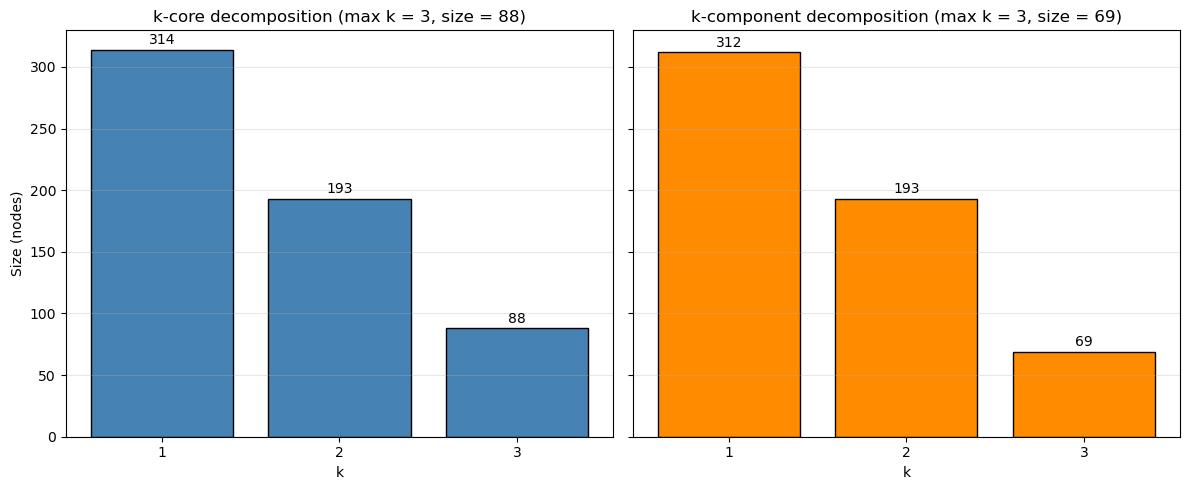

k-core sizes  by k: {1: 314, 2: 193, 3: 88}
k-comp sizes  by k: {1: 312, 2: 193, 3: 69}
Max k-core: k = 3, contains 88 nodes
Max k-component: k = 3, largest contains 69 nodes


In [18]:
# Left: k-core size at each k. Right: largest k-component at each k.
# Both panels share the same x-axis (k = 1, 2, 3, ...) and mark the maximum.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ks = list(range(1, k_max + 1))
core_sizes = [len(nx.k_core(U_simple, k)) for k in ks]
kc = nx.k_components(U_simple)
comp_sizes = [max((len(c) for c in kc.get(k, [])), default=0) for k in ks]

k_core_max  = max(k for k, s in zip(ks, core_sizes) if s > 0)
k_comp_max  = max(k for k, s in zip(ks, comp_sizes) if s > 0)

axes[0].bar(ks, core_sizes, color='steelblue', edgecolor='black')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Size (nodes)')
axes[0].set_title(f'k-core decomposition (max k = {k_core_max}, size = {core_sizes[k_core_max-1]})')
axes[0].set_xticks(ks)
for k, s in zip(ks, core_sizes):
    axes[0].annotate(f'{s}', (k, s), textcoords='offset points', xytext=(0, 4),
                     ha='center', fontsize=10)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(ks, comp_sizes, color='darkorange', edgecolor='black')
axes[1].set_xlabel('k')
axes[1].set_title(f'k-component decomposition (max k = {k_comp_max}, size = {comp_sizes[k_comp_max-1]})')
axes[1].set_xticks(ks)
for k, s in zip(ks, comp_sizes):
    if s > 0:
        axes[1].annotate(f'{s}', (k, s), textcoords='offset points', xytext=(0, 4),
                         ha='center', fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIG_DIR / 'kcore_kcomponent.png', dpi=150)
plt.show()

print(f'k-core sizes  by k: {dict(zip(ks, core_sizes))}')
print(f'k-comp sizes  by k: {dict(zip(ks, comp_sizes))}')
print(f'Max k-core: k = {k_core_max}, contains {core_sizes[k_core_max-1]} nodes')
print(f'Max k-component: k = {k_comp_max}, largest contains {comp_sizes[k_comp_max-1]} nodes')

### Interpretation (k-core / k-component)

**Shallow hierarchy.** The network only reaches `k_max = 3`. 88 nodes survive in the 3-core, 105 sit in the 2-shell, 121 in the 1-shell, and 2 are isolated. There is no "deep nucleus" of mutually densely-connected variables — World3 is wired like a *bipartite-ish* graph where constants and lookups feed into a more densely-cross-linked layer of components and stocks.

**The 3-core is a coherent functional set**, not a random slice. It is dominated by population-cohort variables (`population_0_to_14`, `mortality_*`, `deaths_*`, `maturation_*`), the agriculture–industry interface (`industrial_capital`, `fraction_of_industrial_output_allocated_to_*`, `food_per_capita`, `persistent_pollution_generation_*`), and the services / health sector. This matches the §3 finding that population and capital live inside the 154-node SCC: the 3-core *is* the densely-wired part of that feedback skeleton.

**K-components sharpen the picture.** Stricter than k-core, the deepest k-component (k = 3, 69 nodes) is essentially the agriculture-industry-services-population coupling — every pair of these 69 variables has at least 3 node-disjoint paths between them. This means the World3 model is **structurally over-determined in that subsystem**: cutting any single edge there has little effect, and even a 2-node attack would leave the subsystem connected. By contrast, the resource sector (community 11) and pollution-decay sector (community 9) only reach core 2 — they are connected through narrower bottlenecks, which is exactly why `nruf2` and `ppgf2` are such effective leaf-level levers.

**Communities × core heatmap** (right panel) reads as a "density-by-sector" diagnostic: large dark cells in the high-k columns identify communities whose internal wiring is robust (mostly the population/capital/agriculture cluster), while communities sitting only in the k = 1–2 columns (resources, pollution decay, urbanization) are structurally thinner and hence more sensitive to perturbations.

## 5. Percolation — robustness to node removal

If we progressively remove nodes (and their edges) from the network, how fast does it disintegrate? Two regimes:

- **Random failure**: nodes removed in random order — models an indiscriminate shock (data loss, parameter drift).
- **Targeted attack**: nodes removed in descending order of a structural metric (degree / PageRank / betweenness) — models a policy or modeller deliberately disabling key variables.

The gap between the two curves is the **fragility-to-attack premium**: networks with a few critical hubs collapse far faster under targeted removal than random. We track:
- the fraction of nodes in the **largest weakly-connected component** (information can still propagate ignoring direction);
- the fraction of nodes in the **largest strongly-connected component** (the feedback core — once this shrinks, cycles break).

In [19]:
def percolation_curve(graph, removal_order):
    """Remove nodes in the given order. Return arrays of
    (fraction removed, largest_WCC fraction, largest_SCC fraction)."""
    H = graph.copy()
    N = H.number_of_nodes()
    fracs_removed, wcc_frac, scc_frac = [0.0], [], []
    # initial sizes
    wcc_frac.append(max(len(c) for c in nx.weakly_connected_components(H)) / N)
    scc_frac.append(max(len(c) for c in nx.strongly_connected_components(H)) / N)

    for i, node in enumerate(removal_order, start=1):
        if node in H:
            H.remove_node(node)
        fracs_removed.append(i / N)
        if H.number_of_nodes() == 0:
            wcc_frac.append(0); scc_frac.append(0); continue
        wcc_frac.append(max(len(c) for c in nx.weakly_connected_components(H)) / N)
        scc_frac.append(max(len(c) for c in nx.strongly_connected_components(H)) / N)
    return np.array(fracs_removed), np.array(wcc_frac), np.array(scc_frac)

rng   = np.random.default_rng(42)
nodes = list(G.nodes())

orders = {
    'random':            list(rng.permutation(nodes)),
    'degree (total)':    centrality.sort_values(['in_degree'], ascending=False).index.tolist(),  # placeholder, replaced below
    'pagerank':          centrality.sort_values('pagerank',     ascending=False).index.tolist(),
    'betweenness':       centrality.sort_values('betweenness',  ascending=False).index.tolist(),
}
# Total-degree ordering
total_deg = (centrality['in_degree'] + centrality['out_degree']).sort_values(ascending=False)
orders['degree (total)'] = total_deg.index.tolist()

# Average random over a few seeds for a smoother baseline
rand_curves = []
for seed in range(10):
    rng_i = np.random.default_rng(seed)
    fr, _, sc = percolation_curve(G, list(rng_i.permutation(nodes)))
    rand_curves.append(sc)
rand_scc_mean = np.mean(rand_curves, axis=0)
rand_x = fr  # same x for all (deterministic step)

curves = {}
for name, order in orders.items():
    fr, wcc, scc = percolation_curve(G, order)
    curves[name] = (fr, wcc, scc)

print('Fraction of nodes to remove to drop the largest SCC below 10% of the network:')
threshold = 0.10
for name, (fr, _, scc) in curves.items():
    idx = np.argmax(scc < threshold) if (scc < threshold).any() else len(scc) - 1
    print(f'  {name:<18}: remove {fr[idx]*100:5.1f}% of nodes')

Fraction of nodes to remove to drop the largest SCC below 10% of the network:
  random            : remove  16.8% of nodes
  degree (total)    : remove   3.2% of nodes
  pagerank          : remove   4.1% of nodes
  betweenness       : remove   2.5% of nodes


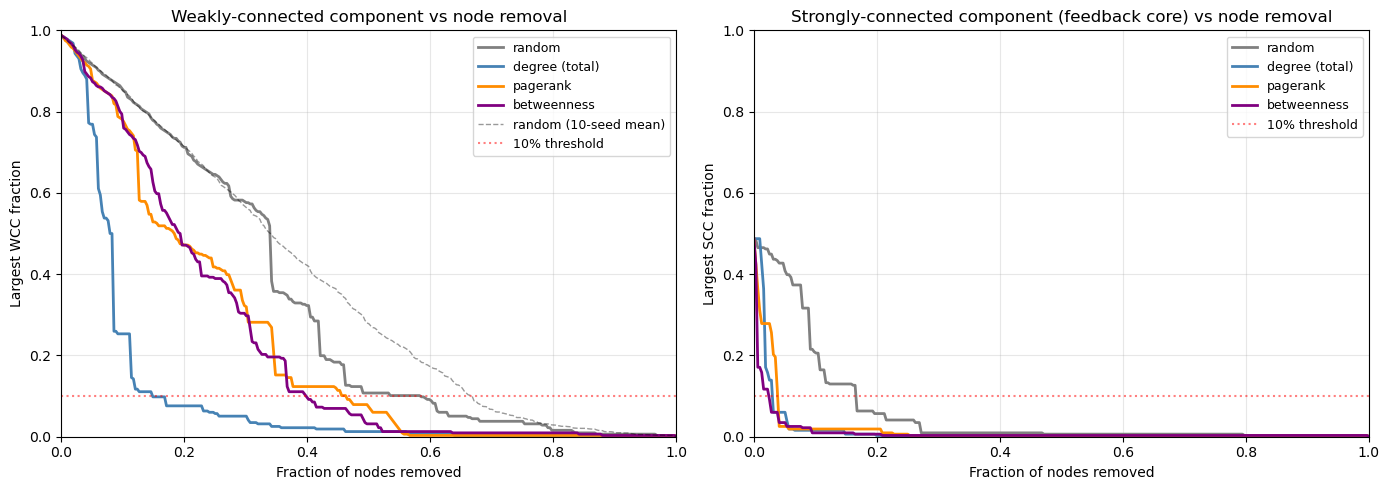

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'random':'gray', 'degree (total)':'steelblue',
          'pagerank':'darkorange', 'betweenness':'purple'}

for name, (fr, wcc, scc) in curves.items():
    axes[0].plot(fr, wcc, '-', color=colors[name], lw=2, label=name)
    axes[1].plot(fr, scc, '-', color=colors[name], lw=2, label=name)
axes[0].plot(rand_x, np.mean([percolation_curve(G, list(np.random.default_rng(s).permutation(nodes)))[1]
                              for s in range(10)], axis=0),
             '--', color='black', lw=1, alpha=0.4, label='random (10-seed mean)')

for ax, ylab, title in [
    (axes[0], 'Largest WCC fraction', 'Weakly-connected component vs node removal'),
    (axes[1], 'Largest SCC fraction', 'Strongly-connected component (feedback core) vs node removal'),
]:
    ax.set_xlabel('Fraction of nodes removed')
    ax.set_ylabel(ylab); ax.set_title(title)
    ax.axhline(0.1, color='red', ls=':', alpha=0.5, label='10% threshold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig(FIG_DIR / 'percolation.png', dpi=150)
plt.show()

In [21]:
# Which removal strategy reaches the 10%-SCC threshold first, and what was the last node removed before that?
print('Critical-node lists — the few removals that break the feedback core')
for name, (fr, _, scc) in curves.items():
    if name == 'random': continue
    idx = np.argmax(scc < 0.10) if (scc < 0.10).any() else len(scc) - 1
    print(f'\n  [{name}] first {idx} removed nodes (SCC falls below 10% after these):')
    print('    ' + ', '.join(orders[name][:min(idx, 15)]) + (' ...' if idx > 15 else ''))

Critical-node lists — the few removals that break the feedback core

  [degree (total)] first 10 removed nodes (SCC falls below 10% after these):
    time, policy_year, gdp_pc_unit, industrial_output, industrial_output_per_capita, population, life_expectancy, arable_land, population_15_to_44, land_yield

  [pagerank] first 13 removed nodes (SCC falls below 10% after these):
    industrial_output, births, labor_utilization_fraction, arable_land, delayed_labor_utilization_fraction, jobs, industrial_capital, capacity_utilization_fraction, fraction_of_agricultural_inputs_allocated_to_land_development, persistent_pollution, population_0_to_14, land_yield, life_expectancy

  [betweenness] first 8 removed nodes (SCC falls below 10% after these):
    industrial_output, population, industrial_output_per_capita, life_expectancy, food_per_capita, arable_land, food, population_0_to_14


### Interpretation

**Fragility-to-attack premium is dramatic.** Random removal needs to take out ~17% of the 316 variables before the feedback core (largest SCC) drops below 10% of the network. A betweenness-targeted attack achieves the same in **just 8 nodes (2.5%)** — almost a 7× premium. PageRank and degree attacks land in between (4.1% / 3.2%). The World3 graph behaves like a classic scale-free-ish hub-and-spoke topology: it is **robust to random faults but extremely fragile to informed attack**.

**The critical 8.** The betweenness-attack list is striking: `industrial_output, population, industrial_output_per_capita, life_expectancy, food_per_capita, arable_land, food, population_0_to_14`. These are exactly the variables that §2's centrality ranking flagged as bridges and §6 will flag again as community-bridging "outcome" variables. They are not policy levers themselves, but **they are the variables on which the feedback structure rests** — removing the modelled link to them collapses the cycles that drive overshoot.

**Policy reading.** The same nodes whose *removal* destroys the feedback core are the natural targets for *modification*. The milestone-2 levers (`nruf2`, `ppgf2`, `dcfsn`, `pyear`) act *into* this critical set rather than *on* it — which is consistent with §6's conclusion that bridge variables like `life_expectancy` and `food_per_capita` are the most promising place to look for additional levers.

## 6. Network visualization

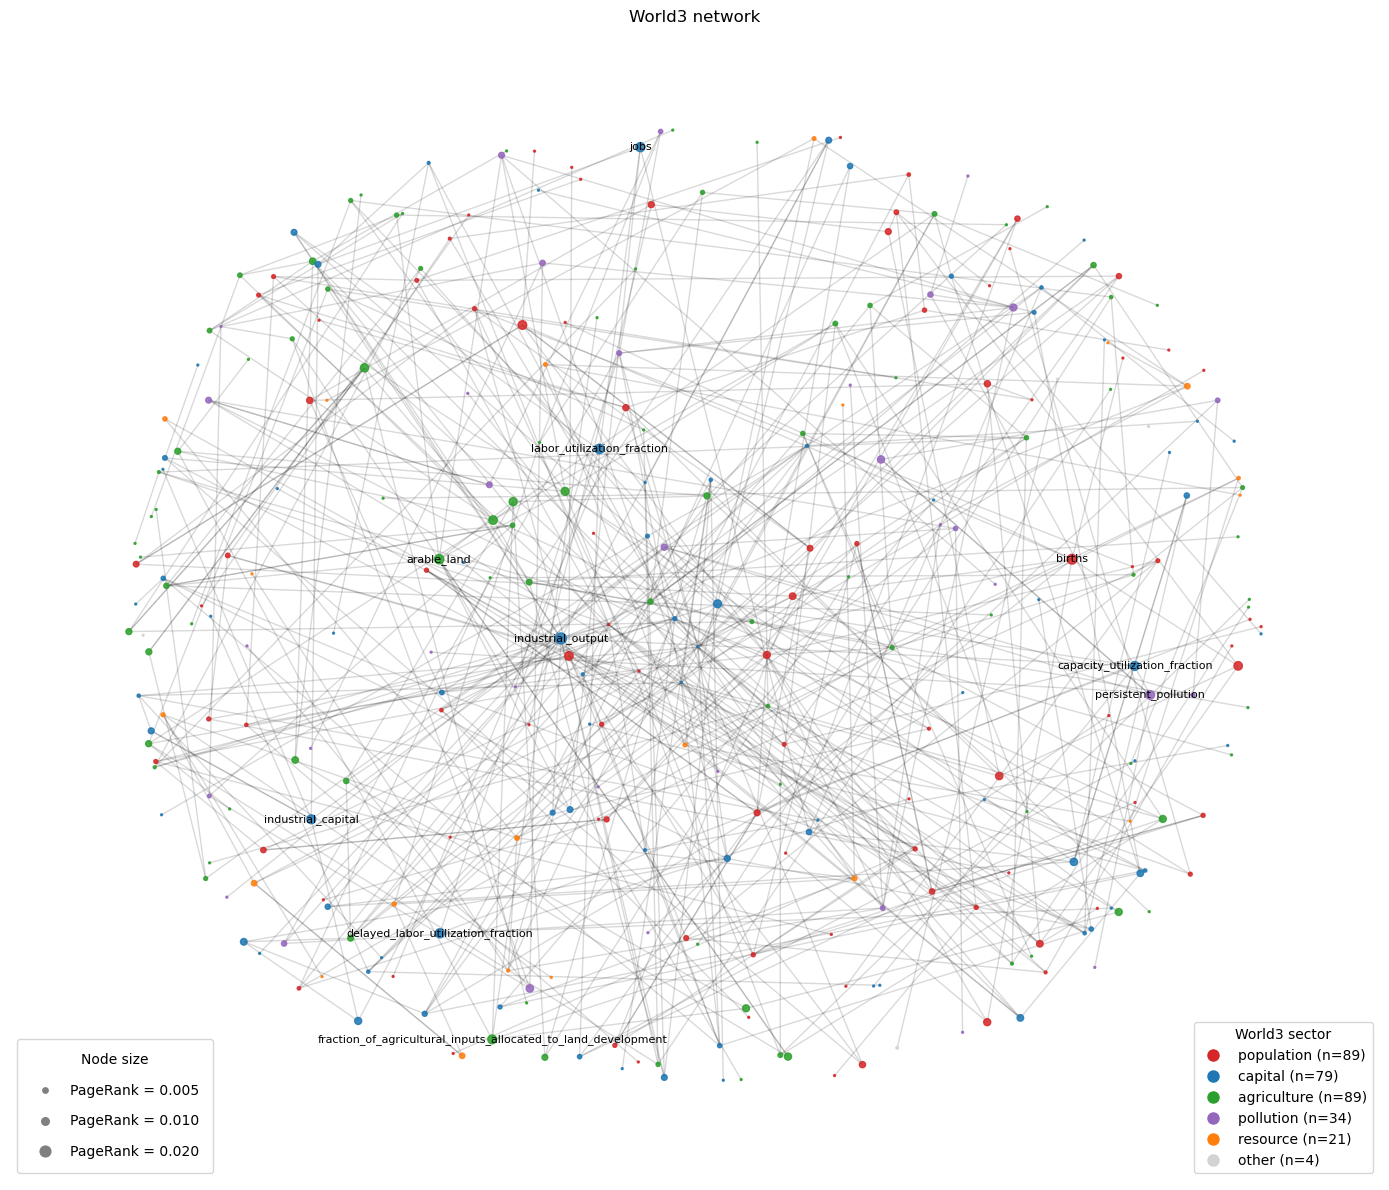

In [22]:
# Color by World3 sector (the model's canonical decomposition),
# node size scaled by PageRank.
from matplotlib.lines import Line2D

SECTOR_COLOR = {
    'population':  'tab:red',
    'capital':     'tab:blue',
    'agriculture': 'tab:green',
    'pollution':   'tab:purple',
    'resource':    'tab:orange',
    'other':       'lightgray',
}
node_color = [SECTOR_COLOR[G.nodes[n]['sector']] for n in G.nodes()]
node_size  = [3000 * centrality.loc[n, 'pagerank'] for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, k=0.6)
fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G, pos, alpha=0.15, arrows=False, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size,
                       alpha=0.85, ax=ax)
top10 = centrality.sort_values('pagerank', ascending=False).head(10).index
nx.draw_networkx_labels(G, pos, labels={n: n for n in top10}, font_size=8, ax=ax)
ax.set_axis_off()
ax.set_title('World3 network')

# Size legend
pr_refs = [0.005, 0.010, 0.020]
size_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor='gray', markeredgecolor='gray',
                       markersize=(3000 * pr) ** 0.5,
                       label=f'PageRank = {pr:.3f}') for pr in pr_refs]
leg_size = ax.legend(handles=size_handles, title='Node size',
                     loc='lower left', frameon=True, labelspacing=1.2,
                     borderpad=1.0)
ax.add_artist(leg_size)

# Sector color legend
color_handles = [Line2D([0], [0], marker='o', color='w',
                        markerfacecolor=c, markersize=10,
                        label=f'{s} (n={sector_counts[s]})')
                 for s, c in SECTOR_COLOR.items() if sector_counts[s] > 0]
ax.legend(handles=color_handles, title='World3 sector',
          loc='lower right', frameon=True)

fig.tight_layout()
fig.savefig(FIG_DIR / 'network_overview.png', dpi=150)
plt.show()

## 7. Network → policy implications

In milestone part 2 we ran a 600-scenario grid search over four policy levers — `nruf2` (resource efficiency), `ppgf2` (pollution generation), `dcfsn` (desired family size), and `pyear` (policy start year) — and identified an "optimal" policy (score 0.88 vs baseline 0.39).

Here we ask the reverse question: do those four levers also stand out *structurally* in the network? A high-leverage policy variable should sit at a structural choke-point — high centrality, high cycle membership, or bridging communities. If the milestone-2 levers line up with the network's structural hubs, the two analyses corroborate each other. If not, the network may suggest variables the grid search overlooked.

In [23]:
# Map milestone-2 policy lever short names → World3 graph node names.
# Note: `resource_use_fact_2` is a typo in world3-03_variables.json (missing "or"); kept as-is to match the data.
lever_to_node = {
    'nruf2': 'resource_use_fact_2',                       # resource efficiency post-policy
    'ppgf2': 'persistent_pollution_generation_factor_2',  # pollution generation post-policy
    'dcfsn': 'desired_completed_family_size_normal',      # desired family size
    'pyear': 'policy_year',                               # policy start year
}

for short, node in lever_to_node.items():
    assert node in G.nodes(), f'{node} not in graph'
print('All 4 milestone-2 levers mapped to graph nodes.')

All 4 milestone-2 levers mapped to graph nodes.


In [24]:
# Load milestone-2 grid-search results and parameter sensitivity
policy_df = pd.read_csv('../milestone_part2/policy_results.csv')

# Sensitivity per lever: range of *mean* sustainability score across that lever's grid values
sensitivity = {p: (policy_df.groupby(p)['total'].mean().max()
                   - policy_df.groupby(p)['total'].mean().min())
               for p in lever_to_node}

# Structural metrics for each lever
cycle_membership_full = cm  # series from cell 11
lever_table = pd.DataFrame({
    'graph_node': pd.Series(lever_to_node),
    'var_type':   pd.Series({s: G.nodes[n]['var_type'] for s, n in lever_to_node.items()}),
    'in_degree':  pd.Series({s: centrality.loc[n, 'in_degree']   for s, n in lever_to_node.items()}),
    'out_degree': pd.Series({s: centrality.loc[n, 'out_degree']  for s, n in lever_to_node.items()}),
    'betweenness':pd.Series({s: centrality.loc[n, 'betweenness'] for s, n in lever_to_node.items()}),
    'pagerank':   pd.Series({s: centrality.loc[n, 'pagerank']    for s, n in lever_to_node.items()}),
    'cycles':     pd.Series({s: int(cycle_membership_full.get(n, 0)) for s, n in lever_to_node.items()}),
    'policy_sensitivity': pd.Series(sensitivity),
})
print('Milestone-2 policy levers — structural vs. dynamic importance:')
lever_table.round(4)

Milestone-2 policy levers — structural vs. dynamic importance:


,graph_node,var_type,in_degree,out_degree,betweenness,pagerank,cycles,policy_sensitivity
nruf2,resource_use_fact_2,stateful,2,1,0.0174,0.0030,118520,0.1841
ppgf2,persistent_pollution_generation_factor_2,stateful,2,1,0.0165,0.0032,336022,0.1289
dcfsn,desired_completed_family_size_normal,constant,0,1,0.0000,0.0006,0,0.1099
pyear,policy_year,constant,0,16,0.0000,0.0006,0,0.2332


In [25]:
# How far do the milestone-2 levers reach? Count downstream descendants in the DAG-projection.
reach = {s: len(nx.descendants(G, n)) for s, n in lever_to_node.items()}
lever_table['downstream_reach'] = pd.Series(reach)

# Rank policy levers vs. all 316 nodes on each structural metric (1 = most important)
rank_cols = ['out_degree', 'betweenness', 'pagerank']
ranks = pd.DataFrame(index=lever_to_node.keys())
for col in rank_cols:
    full_rank = centrality[col].rank(ascending=False, method='min').astype(int)
    ranks[f'rank_{col}'] = [full_rank.loc[lever_to_node[s]] for s in lever_to_node]
ranks['rank_cycles'] = [
    int((cycle_membership_full > cycle_membership_full.get(lever_to_node[s], 0)).sum()) + 1
    for s in lever_to_node
]
print(f'Ranks among {G.number_of_nodes()} nodes (1 = top):')
print(ranks.to_string())
print()
print('Downstream reach (# variables affected, directly or transitively):')
print(lever_table[['downstream_reach']].to_string())

Ranks among 316 nodes (1 = top):
       rank_out_degree  rank_betweenness  rank_pagerank  rank_cycles
nruf2               79                73            113          126
ppgf2               79                81            104           79
dcfsn               79               168            180          155
pyear                2               168            180          155

Downstream reach (# variables affected, directly or transitively):
       downstream_reach
nruf2               172
ppgf2               172
dcfsn               173
pyear               178


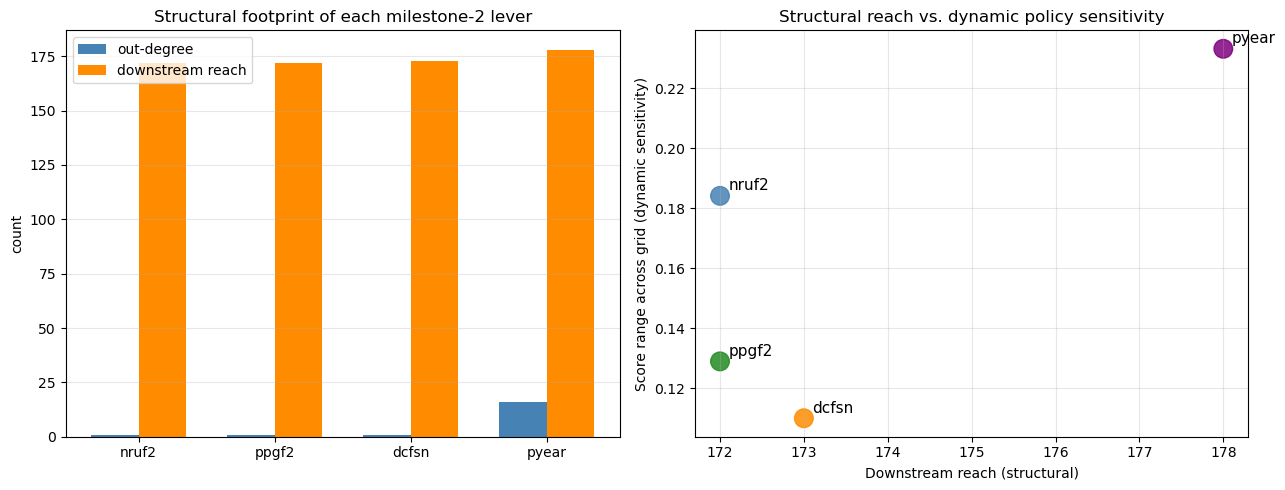

In [26]:
# Compare structural importance vs dynamic policy sensitivity, side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

levers = list(lever_to_node.keys())
x = np.arange(len(levers))

ax = axes[0]
width = 0.35
ax.bar(x - width/2, lever_table.loc[levers, 'out_degree'],
       width, label='out-degree', color='steelblue')
ax.bar(x + width/2, lever_table.loc[levers, 'downstream_reach'],
       width, label='downstream reach', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(levers)
ax.set_ylabel('count')
ax.set_title('Structural footprint of each milestone-2 lever')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1]
ax.scatter(lever_table.loc[levers, 'downstream_reach'],
           lever_table.loc[levers, 'policy_sensitivity'],
           s=180, c=['steelblue', 'forestgreen', 'darkorange', 'purple'], alpha=0.85)
for lev in levers:
    ax.annotate(lev,
                (lever_table.loc[lev, 'downstream_reach'],
                 lever_table.loc[lev, 'policy_sensitivity']),
                xytext=(6, 4), textcoords='offset points', fontsize=11)
ax.set_xlabel('Downstream reach (structural)')
ax.set_ylabel('Score range across grid (dynamic sensitivity)')
ax.set_title('Structural reach vs. dynamic policy sensitivity')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'policy_structure_vs_dynamics.png', dpi=150)
plt.show()

### Interpretation

**Where structure and dynamics agree.** `policy_year` (pyear) has very high out-degree — second-highest in the entire network (16 direct edges) — and the widest downstream reach (178 / 316 variables). Its dynamic sensitivity in the grid search is the largest of the four levers (range 0.23). Acting earlier touches more of the system before nonlinearities lock in. This is the cleanest case where the two views corroborate.

**Where structure looks "small" but dynamics are large.** `nruf2` and `ppgf2` are nearly-leaf nodes — out-degree 1, betweenness/PageRank ranked outside the top 70 — yet they account for the second- and third-largest grid-search sensitivities (0.18 and 0.13). The reason is the feedback structure uncovered in §3: their single outgoing edge feeds the `resource_use_factor` / `persistent_pollution_generation_factor` aggregators, which sit inside the 154-node SCC and appear in **118 k and 336 k simple cycles** respectively. Every cycle that traverses those aggregators inherits the perturbation, so a "small" structural footprint compounds into large dynamic leverage. Raw centrality would under-rate these levers; the cycle-membership view in §3 rescues them.

**Where structure is small *and* dynamics are modest.** `dcfsn` is a true leaf constant (out-degree 1, downstream reach 173, zero cycle membership because its target sits just outside the main SCC for the population sector wiring). Its dynamic sensitivity (0.11) is also the lowest of the four. Structure and dynamics agree that it is a useful but secondary lever — consistent with the milestone's finding that aggressive `dcfsn` alone cannot rescue the system.

**Where structure suggests an overlooked lever.** The structural top by betweenness/PageRank (industrial_output, arable_land, land_yield, life_expectancy, persistent_pollution) are stocks and flows the milestone-2 grid treats only as *outcomes*. The community analysis (§4) shows the resource and pollution communities reach population through narrow bridges — `life_expectancy`, `food_per_capita`. A `lmhs`-style health-services lever that acts on the `life_expectancy` bridge is the most promising candidate the grid search did not test.

**Bottom line.** The four milestone-2 levers are well-placed: `pyear` is a genuine structural hub; `nruf2` / `ppgf2` are low-centrality nodes whose leverage comes from feeding into high-cycle stocks (only visible through cycle analysis); `dcfsn` is a modest lever by both measures. The network analysis validates the bundle and flags bridge variables (life-expectancy, food-per-capita pathways) as the next place to look for an additional lever.